# Experiment No. 4 — Frequency Domain Image Filtering using Fourier Transform

* **Name:** Abhigyan Dubey
* **Course & Branch:** B.TECH CSE
* **CUID:** CU24250059
* **SUBJECT:** Computer Vision Lab
* **SEM & Section:** 5th SEM, "B"

**Aim:** Implement image filtering in the frequency domain using the Fourier Transform (DFT), and analyze Low-Pass and High-Pass filtering for noise removal, enhancement, and feature preservation.

Upload your own image in Step 1 — it works with any photo.

---

### Steps 1–2: Import libraries, upload image, compute the DFT

Saving wp14315669-aventurine-hsr-wallpapers.jpg to wp14315669-aventurine-hsr-wallpapers.jpg


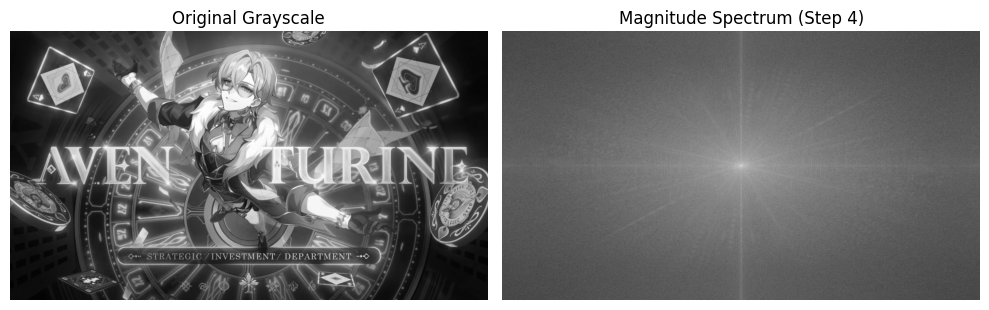

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()                      # choose an image from your laptop
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

# Discrete Fourier Transform
dft = cv2.dft(gray, flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)                # Step 3: shift zero-frequency to center

magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(gray, cmap='gray'); plt.title("Original Grayscale"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(magnitude_spectrum, cmap='gray'); plt.title("Magnitude Spectrum (Step 4)"); plt.axis('off')
plt.tight_layout(); plt.show()

### Steps 5–7: Design Low-Pass & High-Pass filters, then reconstruct via Inverse DFT

A circular mask centered on the shifted spectrum keeps (Low-Pass) or removes (High-Pass) the low frequencies within radius `r`.

In [2]:
rows, cols = gray.shape
crow, ccol = rows // 2, cols // 2
r = 30  # filter radius - smaller = more aggressive filtering

# Low-Pass mask: keep center (low frequencies), block the rest
mask_lp = np.zeros((rows, cols, 2), np.uint8)
cv2.circle(mask_lp, (ccol, crow), r, (1, 1), -1)

# High-Pass mask: block center (low frequencies), keep the rest
mask_hp = 1 - mask_lp

def reconstruct(dft_shifted, mask):
    filtered_shift = dft_shifted * mask
    filtered = np.fft.ifftshift(filtered_shift)
    img_back = cv2.idft(filtered)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
    return cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

low_pass_img = reconstruct(dft_shift, mask_lp)
high_pass_img = reconstruct(dft_shift, mask_hp)

### Step 8: Compare original, spectrum, low-pass, and high-pass results

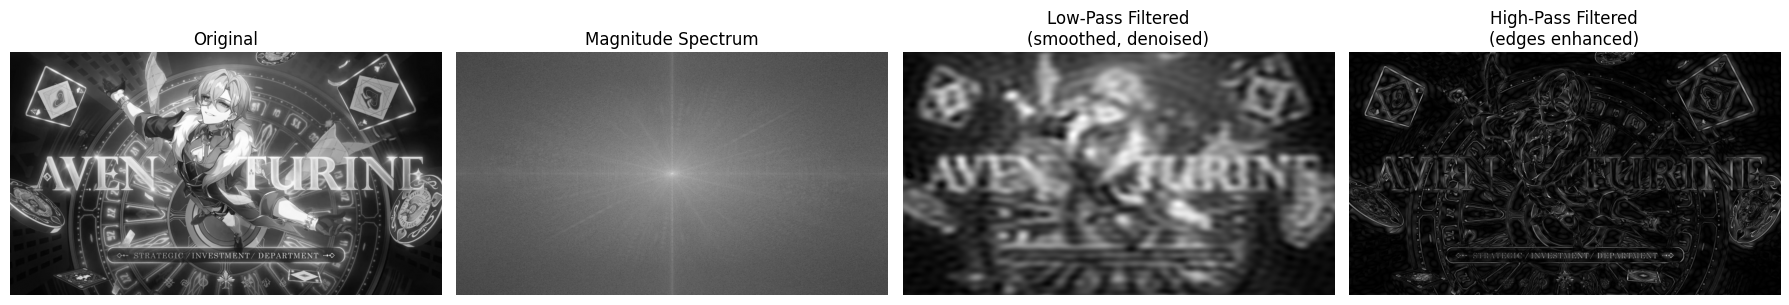

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ["Original", "Magnitude Spectrum", "Low-Pass Filtered\n(smoothed, denoised)", "High-Pass Filtered\n(edges enhanced)"]
images = [gray, magnitude_spectrum, low_pass_img, high_pass_img]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Steps 9–10: Analysis & Observations

- **Low-pass filtering** removes high-frequency detail (edges, noise, fine texture), producing a smoother, blurred image — useful for noise reduction.
- **High-pass filtering** removes low-frequency content (smooth shading/background), keeping only edges and fine details — useful for edge/feature enhancement.
- Frequency-domain filtering separates an image's content by *rate of intensity change*, letting us target noise or edges directly, rather than relying only on local pixel neighborhoods as in spatial filtering.
- Applications: medical image denoising, satellite image restoration, biometric feature enhancement, and general image restoration pipelines.

---

## Questions

**Q1. What is the Fourier Transform? Why is it important in digital image processing?**

**Ans:** The Fourier Transform decomposes an image into its constituent sinusoidal frequency components, converting it from the spatial (pixel) domain to the frequency domain. It's important because it enables filtering, compression, and analysis based on frequency content (e.g., separating noise from edges) — operations that are difficult or expensive to perform directly on pixel values.

**Q2. Differentiate between the spatial domain and the frequency domain.**

**Ans:** The spatial domain represents an image directly as pixel intensity values arranged in a 2D grid, where operations (like convolution/blurring) act on neighboring pixels. The frequency domain represents the same image in terms of the frequency and amplitude of its sinusoidal components, where operations (like filtering) act by selectively keeping or removing frequency bands.

**Q3. What is the significance of the Discrete Fourier Transform (DFT) in image processing?**

**Ans:** The DFT is the discrete version of the Fourier Transform, suited for digital (sampled) images. It converts an image into a frequency spectrum, allowing frequency-selective operations such as noise removal, sharpening, and compression, and forms the mathematical basis for many enhancement and restoration algorithms.

**Q4. Explain the purpose of shifting the zero-frequency component to the center of the frequency spectrum.**

**Ans:** By default, the DFT output places the zero (DC) frequency at the corners of the spectrum, which is hard to interpret visually. Shifting (`fftshift`) moves the zero-frequency component to the center, so frequencies increase radially outward — making it much easier to visualize, and to design centered circular filters like our low/high-pass masks.

**Q5. Compare Low-Pass Frequency Filters and High-Pass Frequency Filters with suitable applications.**

**Ans:** A Low-Pass Filter retains low frequencies (smooth/slowly changing regions) and suppresses high frequencies, producing a blurred/smoothed image — used for noise reduction and smoothing. A High-Pass Filter retains high frequencies (edges, fine detail) and suppresses low frequencies, producing an edge-enhanced image — used for sharpening and edge/feature detection.

**Q6. What is the role of the Inverse Fourier Transform (IDFT) in image reconstruction?**

**Ans:** After filtering in the frequency domain, the IDFT converts the modified frequency-domain representation back into the spatial (pixel) domain, reconstructing a visible, filtered image that reflects the changes made to its frequency content.

**Q7. Why is frequency domain filtering preferred for certain image enhancement tasks?**

**Ans:** It allows precise, targeted control over specific frequency bands (e.g., removing periodic noise or isolating fine texture) that would require complex or multiple spatial kernels to achieve directly, and can be computationally efficient for large filters via the Fast Fourier Transform (FFT).

**Q8. Mention four real-world applications where Fourier Transform is used in computer vision and image analysis.**

**Ans:** (1) Medical image denoising and enhancement (MRI/CT scans), (2) satellite/remote sensing image restoration, (3) biometric systems (fingerprint/iris feature enhancement), and (4) image compression (e.g., JPEG uses a related transform, DCT).

**Q9. Compare frequency domain filtering with spatial domain filtering based on computational efficiency and practical applications.**

**Ans:** Spatial filtering (convolution with small kernels) is generally faster and simpler for small, local operations like basic blurring or edge detection. Frequency domain filtering, using the FFT, becomes more computationally efficient for large kernels or global filtering operations, and it uniquely enables precise selective frequency manipulation that's impractical to replicate exactly with small spatial kernels.

**Q10. How does frequency domain filtering improve the performance of image restoration and feature extraction techniques?**

**Ans:** By isolating and removing unwanted frequency components (like periodic noise) while preserving the frequencies that carry meaningful structure, frequency domain filtering produces cleaner, more informative images. This leads to more reliable edge/feature detection and better results in downstream restoration and recognition tasks.